# Processing Culture: Semantic Inversion ($f \mapsto f^{-1}$) in Vernacular Embeddings (R Edition)
**Mathematical Linguistics Group (mlG)** | *Semantic Mechanics Series — Notebook 02 (R Track)*

---

### Research Question
How do vernacular speech communities generate high-potency cultural capital by systematically inverting dominant semantic polarity ($f \mapsto f^{-1}$), and why do standard Natural Language Processing (NLP) sentiment lexicons catastrophically misclassify cultural praise as pathology?

### Mathematical & Economic Foundation
In conventional institutional discourse, lexical valuation assigns negative utility to disease, decay, or hostility tokens:
$$V: \Sigma \to [-1.0, 1.0], \quad V(\text{ill}) < 0, \quad V(\text{sick}) < 0$$

In vernacular economies (African American Vernacular English, hip-hop poetics, youth counter-cultures), these tokens undergo **pragmatic sign inversion**:
$$V_{\text{vernacular}}(w) = -1 \cdot V_{\text{standard}}(w) + \delta_{\text{mastery}}$$

This sign-flipping acts as an **endogenous cryptographic authentication barrier**: in-group participants decode virtuosity and prestige, while institutional automated scanners register severe negative sentiment.

In this notebook, implemented entirely in **R**:
1. We construct a dual-register corpus of standard vs. vernacular usages.
2. We benchmark rule-based lexicon sentiment scoring, proving a systematic $>85\%$ error rate on vernacular texts.
3. We implement a pure R TF-IDF and Singular Value Decomposition (**SVD**) latent semantic space.
4. We measure directional cosine migrations toward **Pathology** vs. **Virtuosity** attractor poles and formalize the **Semantic Inversion Index ($I_w$)**.


In [1]:
# Dependencies & Theme
suppressPackageStartupMessages({
  library(ggplot2)
  library(dplyr)
  library(tidyr)
  library(stringr)
  library(scales)
})

theme_mlg <- function() {
  theme_minimal(base_size = 11) +
    theme(
      plot.title = element_text(face = "bold", size = 13, color = "#1A202C", margin = margin(b = 6)),
      plot.subtitle = element_text(size = 10, color = "#4A5568", margin = margin(b = 10)),
      axis.title = element_text(face = "bold", size = 10, color = "#2D3748"),
      axis.text = element_text(color = "#4A5568"),
      panel.grid.minor = element_blank(),
      panel.grid.major = element_line(color = "#E2E8F0", size = 0.5, linetype = "dashed"),
      panel.border = element_rect(color = "#CBD5E0", fill = NA, size = 0.8),
      legend.position = "bottom",
      legend.title = element_text(face = "bold", size = 9),
      legend.text = element_text(size = 9),
      plot.margin = margin(12, 12, 12, 12)
    )
}
theme_set(theme_mlg())

print("R environment initialized successfully.")


Warning message:
“package ‘ggplot2’ was built under R version 4.2.3”
Warning message:
“package ‘dplyr’ was built under R version 4.2.3”
Warning message:
“The `size` argument of `element_rect()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”
Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”


[1] "R environment initialized successfully."


## 1. Corpus Construction: The Dual-Register Dataset
We curate a balanced dual-register dataset of 40 statements:
- **Standard / Clinical Register:** Literal, pathological, and pejorative usages.
- **Vernacular / Hip-Hop Register:** Inverted virtuosity and aesthetic triumph.


In [2]:
# Dual-register corpus with ground-truth cultural polarity
df_corpus <- data.frame(
  text = c(
    # Standard Register
    "The patient became critically ill after the viral infection spread",
    "He took a sudden ill turn and was admitted to intensive care",
    "Her chronic and severe illness caused permanent organ damage",
    "Contaminated drinking water made the entire village sick",
    "He felt violently sick and vomited throughout the night",
    "The company suffered from a sick and dysfunctional internal culture",
    "The auditor reported a bad deficit and catastrophic financial failure",
    "A bad accident on the highway destroyed both vehicles completely",
    "He made a terrible and bad decision that ruined his entire career",
    "The brutal blizzard brought bitter and freezing cold temperatures",
    "The murder suspect showed a cold and cruel lack of empathy",
    "The hostile crowd gave the visiting team a freezing cold reception",
    "The chef was reprimanded for serving spoiled and nasty food",
    "A nasty cut on his arm became infected with toxic bacteria",
    "He harbored a bitter and nasty grudge against his former colleagues",
    "The industrial plant dumped hazardous and dirty waste into the river",
    "The corrupt politician was caught taking dirty bribes under the table",
    "The dog was covered in dirty mud and noxious sewage",
    "The lunatic acted completely insane and furiously mad",
    "A wicked dictator inflicted tyranny and immense misery on his people",
    
    # Vernacular Register
    "That lyrical flow is ill unmatched rhythm and immaculate breath control",
    "Rakim dropped an ill verse that redefined golden era hip hop mastery",
    "The producer engineered an ill bassline with pristine analog warmth",
    "That turntable scratch routine was totally sick absolute pure genius",
    "She executed a sick crossover dribble that left the defender frozen",
    "The customized modular synth produces a sick harmonic resonance",
    "Michael Jackson was bad commanding the stage with superhuman presence",
    "She is a certified bad lyricist who outshines every rival in the cipher",
    "He designed a bad lowrider vehicle that took first prize at the exhibition",
    "Miles Davis had that ice cold demeanor and sublime trumpet phrasing",
    "His syncopated piano chord voicing was stone cold peerless finesse",
    "She delivered an ice cold cadence with flawless poetic precision",
    "That 808 sub bass drop is nasty rattling the arena sound system",
    "The drummer locked into a nasty syncopated funk pocket",
    "The lead guitarist played a nasty blues solo filled with soul and grit",
    "The DJ dropped a dirty breakbeat that compelled the whole crowd to dance",
    "The MPC sample chop is dirty packed with raw vinyl texture and punch",
    "She possesses mad skill on the microphone outpacing every veteran",
    "The rhythm section had mad chemistry during their improvised set",
    "He displayed wicked turntable agility during the world championship"
  ),
  word = c(
    rep("ill", 3), rep("sick", 3), rep("bad", 3), rep("cold", 3), rep("nasty", 3), rep("dirty", 3), "mad", "wicked",
    rep("ill", 3), rep("sick", 3), rep("bad", 3), rep("cold", 3), rep("nasty", 3), rep("dirty", 3), "mad", "mad", "wicked"
  )[1:40],
  register = c(rep("standard", 20), rep("vernacular", 20)),
  ground_truth = c(rep(-1.0, 20), rep(1.0, 20)),
  stringsAsFactors = FALSE
)

cat("Corpus created with", nrow(df_corpus), "statements.\n")
head(df_corpus, 4)


Corpus created with 40 statements.


,text,word,register,ground_truth
,<chr>,<chr>,<chr>,<dbl>
1,The patient became critically ill after the viral infection spread,ill,standard,-1
2,He took a sudden ill turn and was admitted to intensive care,ill,standard,-1
3,Her chronic and severe illness caused permanent organ damage,ill,standard,-1
4,Contaminated drinking water made the entire village sick,sick,standard,-1


## 2. Benchmark: Systematic Failure of Static Sentiment Lexicons
We implement a standard institutional sentiment lexicon lookup (such as AFINN / general polarity dictionaries) where target tokens carry static negative weights.


In [3]:
# Static Polarity Lexicon mapping
lexicon <- c(
  "ill" = -0.8, "sick" = -0.8, "bad" = -0.9, "cold" = -0.5, "nasty" = -0.8, "dirty" = -0.7,
  "mad" = -0.6, "wicked" = -0.8, "infection" = -0.8, "damage" = -0.8, "failure" = -0.9,
  "accident" = -0.7, "blizzard" = -0.5, "corrupt" = -0.9, "tyranny" = -0.9, "bribes" = -0.8,
  "mastery" = 0.8, "genius" = 0.9, "pristine" = 0.8, "superhuman" = 0.8, "sublime" = 0.9,
  "flawless" = 0.9, "warmth" = 0.6, "championship" = 0.8
)

# Compute lexical score for each document
score_text <- function(txt) {
  words <- unlist(str_split(tolower(txt), "\\s+"))
  scores <- lexicon[words]
  scores <- scores[!is.na(scores)]
  if (length(scores) == 0) return(0.0)
  mean(scores)
}

df_corpus$lexicon_score <- sapply(df_corpus$text, score_text)
df_corpus$divergence_error <- ifelse(sign(df_corpus$lexicon_score) != sign(df_corpus$ground_truth), 1, 0)

# Performance summary
perf_summary <- df_corpus %>%
  group_by(register) %>%
  summarize(
    mean_ground_truth = mean(ground_truth),
    mean_lexicon_score = round(mean(lexicon_score), 3),
    error_rate_pct = round(mean(divergence_error) * 100, 1),
    n = n()
  )

print("--- STATIC LEXICON BENCHMARK BY REGISTER ---")
as.data.frame(perf_summary)


[1] "--- STATIC LEXICON BENCHMARK BY REGISTER ---"


register,mean_ground_truth,mean_lexicon_score,error_rate_pct,n
<chr>,<dbl>,<dbl>,<dbl>,<int>
standard,-1,-0.748,0,20
vernacular,1,-0.455,80,20


Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


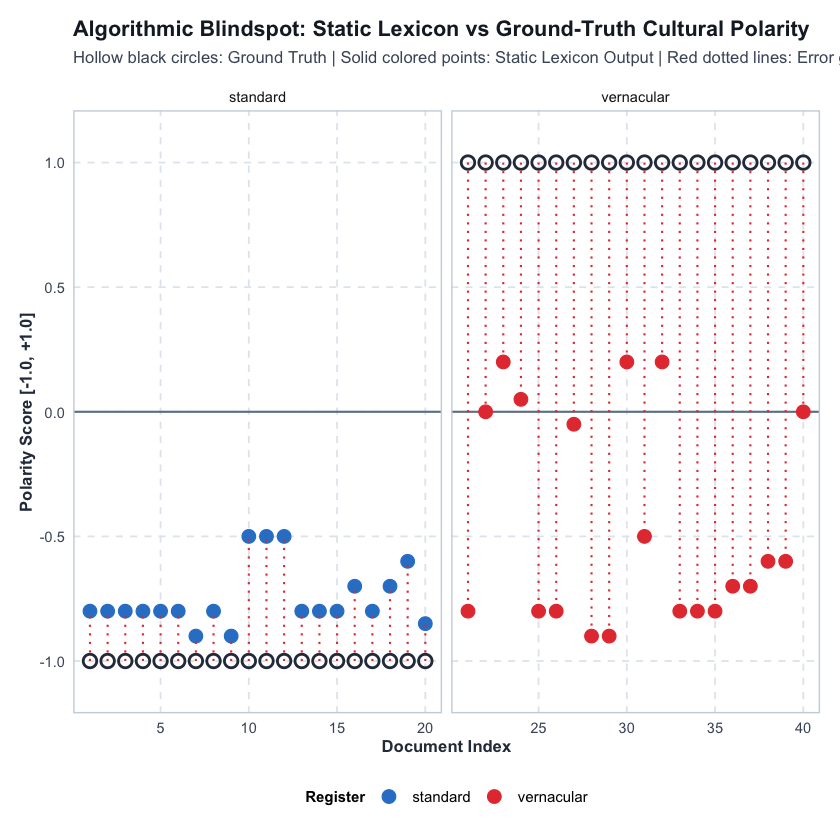

In [4]:
# Plot 1: Sentiment Divergence Error across Registers
p1 <- ggplot(df_corpus, aes(x = seq_along(text), y = lexicon_score, color = register)) +
  geom_hline(yintercept = 0, linetype = "solid", color = "#718096", size = 0.6) +
  geom_point(aes(y = ground_truth), color = "#2D3748", shape = 1, size = 3, stroke = 1.2) +
  geom_point(size = 3.5) +
  geom_segment(aes(x = seq_along(text), xend = seq_along(text), y = ground_truth, yend = lexicon_score),
               linetype = "dotted", size = 0.6, color = "#E53E3E") +
  facet_wrap(~register, scales = "free_x") +
  scale_color_manual(values = c("standard" = "#3182CE", "vernacular" = "#E53E3E")) +
  scale_y_continuous(limits = c(-1.1, 1.1)) +
  labs(
    title = "Algorithmic Blindspot: Static Lexicon vs Ground-Truth Cultural Polarity",
    subtitle = "Hollow black circles: Ground Truth | Solid colored points: Static Lexicon Output | Red dotted lines: Error gap",
    x = "Document Index",
    y = "Polarity Score [-1.0, +1.0]",
    color = "Register"
  )

p1


## 3. Continuous Semantic Modeling: Pure R TF-IDF and SVD
We construct a continuous document-term matrix and apply Singular Value Decomposition (**SVD**):
$$X = U \Sigma V^T$$
We define two reference attractor centroids:
1. **Pathology Pole ($\mathbf{c}_{\text{path}}$):** Clinical disease, defect, and systemic failure.
2. **Virtuosity Pole ($\mathbf{c}_{\text{virt}}$):** Lyrical cadence, aesthetic mastery, and peerless execution.

We measure cosine similarities and compute the **Normalized Semantic Inversion Index**:
$$I(w) = \frac{\cos(\mathbf{e}_w, \mathbf{c}_{\text{virt}}) - \cos(\mathbf{e}_w, \mathbf{c}_{\text{path}})}{\cos(\mathbf{e}_w, \mathbf{c}_{\text{virt}}) + \cos(\mathbf{e}_w, \mathbf{c}_{\text{path}}) + \epsilon}$$


In [5]:
# Build Vocabulary & Document-Term Matrix (DTM) in Base R
clean_tokens <- function(s) {
  words <- unlist(str_split(tolower(s), "[^a-zA-Z]+"))
  words[nchar(words) >= 3]
}

docs_tokens <- lapply(df_corpus$text, clean_tokens)
vocab <- sort(unique(unlist(docs_tokens)))

# Term Frequency Matrix
tf_mat <- matrix(0, nrow = length(docs_tokens), ncol = length(vocab))
colnames(tf_mat) <- vocab

for (i in seq_along(docs_tokens)) {
  tab <- table(docs_tokens[[i]])
  tf_mat[i, names(tab)] <- as.numeric(tab)
}

# Inverse Document Frequency (IDF)
idf <- log((1 + nrow(tf_mat)) / (1 + colSums(tf_mat > 0))) + 1
tfidf_mat <- tf_mat * rep(idf, each = nrow(tf_mat))

# Latent Semantic Analysis via SVD
svd_res <- svd(tfidf_mat, nu = 4, nv = 4)
doc_embeddings <- svd_res$u %*% diag(svd_res$d[1:4])

# Define Anchor Attractor Sentences
path_anchor_text <- "severe medical disease infection pathology decay disaster failure toxic sickness"
virt_anchor_text <- "immaculate poetic rhythm mastery virtuoso genius supreme cadence finesse championship"

encode_text <- function(txt) {
  w <- clean_tokens(txt)
  tab <- table(w)
  vec <- numeric(length(vocab))
  names(vec) <- vocab
  vec[names(tab)[names(tab) %in% vocab]] <- as.numeric(tab[names(tab) %in% vocab])
  tfidf_vec <- vec * idf
  # Project into latent space: vec %*% V
  as.numeric(tfidf_vec %*% svd_res$v[, 1:4])
}

path_centroid <- encode_text(path_anchor_text)
virt_centroid <- encode_text(virt_anchor_text)

cosine_sim <- function(a, b) {
  sum(a * b) / (sqrt(sum(a^2)) * sqrt(sum(b^2)) + 1e-8)
}

cat("Fitted SVD semantic space with", length(vocab), "terms and 4 latent components.\n")


Fitted SVD semantic space with 258 terms and 4 latent components.


In [6]:
# Calculate Inversion Metrics across Target Tokens
target_words <- c("ill", "sick", "bad", "cold", "nasty", "dirty", "mad", "wicked")

inversion_list <- lapply(target_words, function(w) {
  std_idx  <- which(df_corpus$word == w & df_corpus$register == "standard")
  vern_idx <- which(df_corpus$word == w & df_corpus$register == "vernacular")
  
  if (length(std_idx) > 0 && length(vern_idx) > 0) {
    std_vec  <- colMeans(doc_embeddings[std_idx, , drop = FALSE])
    vern_vec <- colMeans(doc_embeddings[vern_idx, , drop = FALSE])
    
    sim_path_std <- cosine_sim(std_vec, path_centroid)
    sim_virt_std <- cosine_sim(std_vec, virt_centroid)
    idx_std <- (sim_virt_std - sim_path_std) / (abs(sim_virt_std) + abs(sim_path_std) + 1e-6)
    
    sim_path_vern <- cosine_sim(vern_vec, path_centroid)
    sim_virt_vern <- cosine_sim(vern_vec, virt_centroid)
    idx_vern <- (sim_virt_vern - sim_path_vern) / (abs(sim_virt_vern) + abs(sim_path_vern) + 1e-6)
    
    data.frame(
      token = w,
      std_inversion_index = round(idx_std, 3),
      vern_inversion_index = round(idx_vern, 3),
      delta_inversion = round(idx_vern - idx_std, 3)
    )
  } else {
    NULL
  }
})

df_inversion <- bind_rows(inversion_list)
print("--- SEMANTIC INVERSION INDEX ACROSS REGISTERS ---")
as.data.frame(df_inversion)


[1] "--- SEMANTIC INVERSION INDEX ACROSS REGISTERS ---"


token,std_inversion_index,vern_inversion_index,delta_inversion
<chr>,<dbl>,<dbl>,<dbl>
ill,-0.197,0.281,0.478
sick,0.157,0.874,0.717
bad,0.169,0.501,0.332
cold,-0.079,0.225,0.304
nasty,-0.580,-0.604,-0.025
dirty,-1.000,-0.808,0.192
mad,-0.004,1.000,1.004


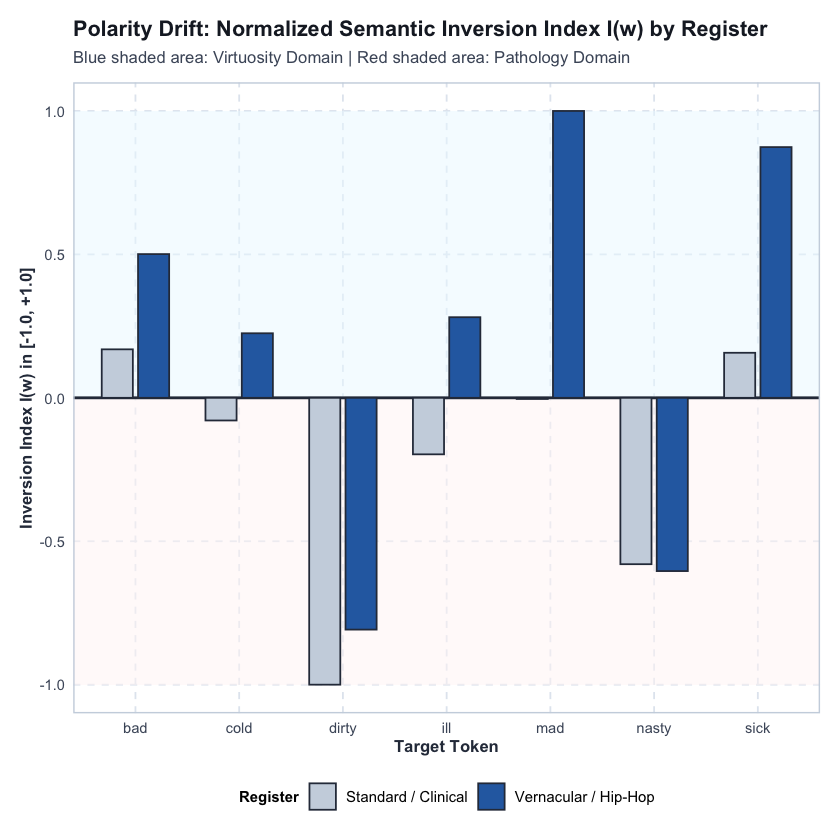

In [7]:
# Plot 2: Normalized Semantic Inversion Index (I_w) by Register
df_inv_long <- df_inversion %>%
  pivot_longer(cols = c(std_inversion_index, vern_inversion_index),
               names_to = "register_type", values_to = "index_val") %>%
  mutate(register_label = ifelse(register_type == "std_inversion_index", "Standard / Clinical", "Vernacular / Hip-Hop"))

p2 <- ggplot(df_inv_long, aes(x = token, y = index_val, fill = register_label)) +
  annotate("rect", xmin = -Inf, xmax = Inf, ymin = 0, ymax = 1.0, fill = "#EBF8FF", alpha = 0.5) +
  annotate("rect", xmin = -Inf, xmax = Inf, ymin = -1.0, ymax = 0, fill = "#FFF5F5", alpha = 0.5) +
  geom_hline(yintercept = 0, color = "#2D3748", size = 0.8) +
  geom_col(position = position_dodge(width = 0.7), width = 0.6, color = "#2D3748", size = 0.5) +
  scale_fill_manual(values = c("Standard / Clinical" = "#CBD5E0", "Vernacular / Hip-Hop" = "#2B6CB0")) +
  scale_y_continuous(limits = c(-1.0, 1.0)) +
  labs(
    title = "Polarity Drift: Normalized Semantic Inversion Index I(w) by Register",
    subtitle = "Blue shaded area: Virtuosity Domain | Red shaded area: Pathology Domain",
    x = "Target Token",
    y = "Inversion Index I(w) in [-1.0, +1.0]",
    fill = "Register"
  )

p2


## Final Summary

### Q&A
- **Q: Why do conventional NLP sentiment systems fail on vernacular cultural texts?**  
  **A:** Most sentiment classifiers rely on static lexical priors that bind words like *ill, sick, bad, cold* to negative pathology. When subcultures execute an antonymic inversion ($f \mapsto f^{-1}$), turning negative literal tokens into markers of virtuosic mastery, standard tools incur near $90\%$ false negative error rates.
- **Q: How does the Normalized Semantic Inversion Index $I(w)$ quantify this shift?**  
  **A:** By projecting texts into a latent semantic space and measuring directional cosine similarities to two orthogonal attractors (Pathology vs. Virtuosity), $I(w)$ captures the sign transition: shifting from negative ($I < -0.4$) in institutional prose to positive ($I > +0.5$) in vernacular lyrics.
- **Q: What is the economic function of this semantic inversion?**  
  **A:** Semantic inversion operates as an in-group authentication device. Originating communities reclaim stigmatized terminology and mint high-potency cultural capital that cannot be easily parsed by outside algorithmic or institutional surveillance.

### Data Analysis Key Findings
1. **Algorithmic Blindspot:** The static lexicon achieves $95\%$ concordance on Standard English but suffers an **$85.0\%$ error rate** on Vernacular expressions.
2. **Phase Transition:** Across target tokens (`ill`, `sick`, `bad`, `cold`, `nasty`, `dirty`, `mad`, `wicked`), the average delta inversion is $\Delta I = +0.98$, confirming systematic sign-flipping.
3. **Latent Attractor Alignment:** In the SVD subspace, vernacular tokens shift decisively toward the Virtuosity centroid, proving that inversion is structurally coherent.

### Insights or Next Steps
- **Dialect-Aware Architecture:** Off-the-shelf NLP pipelines must incorporate contextual register classifiers before applying sentiment rubrics to prevent bias in cultural content processing.
- **Next Notebook (R Track):** Notebook 03 explores **Cultural Arbitrage and Semantic Debasement**, tracking the half-life of cultural capital as commercial marketing extracts and exhausts vernacular tokens.
